In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import boto3
import datetime as dt
from tqdm import tqdm
import shutil
from datetime import datetime, timedelta

try:
    import optbinning
except:
    ! pip install optbinning

try:
    import catboost
except:
    ! pip install catboost

In [2]:
dtm_now = dt.datetime.now()
print(f'Latest run date: {dtm_now}')

Latest run date: 2025-03-10 23:29:05.221329


#### Functions

In [3]:
def get_tier(flt_ecnl, dict_tiers):
    if flt_ecnl <= dict_tiers['A1']:
        return 'A1'
    elif flt_ecnl <= dict_tiers['A']:
        return 'A'
    elif flt_ecnl <= dict_tiers['B']:
        return 'B'
    elif flt_ecnl <= dict_tiers['C']:
        return 'C'
    elif flt_ecnl <= dict_tiers['D']:
        return 'D'
    else:
        return 'Decline'

#### Constants

In [4]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

# output
str_dirname_output = './output'

flt_factor_24_to_72 = 2.36

# dict tiers
dict_tiers = {
    'A1': 0.0760,
    'A': 0.1320,
    'B': 0.2650,
    'C': 0.3220,
    'D': 0.3500, 
}

dict_sort = {
    'A1': 1,
    'A': 2,
    'B': 3,
    'C': 4,
    'D': 5,
    'Decline': 6,
}

dict_map = {
    0: 'No',
    1: 'Yes',
}

Project: 20250307-funded-trends
Task: 08_analysis


#### Make output dir

In [5]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Data dictionary

In [6]:
# get descriptions
df_dict = pd.read_csv('./data_dictionary.csv')
dict_map_descriptions = dict(zip(df_dict['feature_name'], df_dict['Description']))
dict_map_descriptions['miles_odometer__app'] = 'Vehicle mileage'
dict_map_descriptions['ENG-loan_to_value'] = 'Loan to value'
dict_map_descriptions['fltgrossmonthly__income_sum'] = 'Monthly income'
dict_map_descriptions['ENG-bk'] = 'Open BK'
dict_map_descriptions['ENG-franchise'] = 'Franchise'
dict_map_descriptions['ENG-wtd_avg'] = 'Auto payment history'

#### Import data

In [7]:
str_filename = 'df.gzip'
str_uri = f's3://{str_project}/07_get_predictions/{str_filename}'
df = pd.read_parquet(str_uri)
# set dtm
df['request_datetime'] = pd.to_datetime(df['request_datetime'])
# sort
df.sort_values(by='request_datetime', ascending=True, inplace=True)
# make request month
df['request_month'] = df['request_datetime'].apply(
    lambda x: str(x)[:7],
)
# rm
df = df[df['request_month'] != '2021-07'].copy()
# show
df

,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,linka006__tu_binned_contribution,inquiryshortterm12month__ln_binned_contribution,addrinputsubjectcount__ln_binned_contribution,g251c__tu_binned_contribution,g095s__tu_binned_contribution,s209a__tu_binned_contribution,inquirynonshortterm12month__ln_binned_contribution,gen13_pd,gen13_lgd,request_month
244,5714301,2021-08-02,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,0,0,Minnesota,Franchise,Minnesota,True,...,-0.081562,-0.040978,-0.014258,0.022693,-0.142548,-0.037731,-0.061136,0.274665,0.289997,2021-08
243,5715405,2021-08-02,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Texas,Franchise,Texas,False,...,-0.065002,-0.040978,0.004595,0.022693,-0.142548,0.018359,0.033394,0.270115,0.390043,2021-08
242,5712032,2021-08-02,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Washington,Franchise,Washington,False,...,0.034744,-0.040978,-0.014258,0.022693,0.059176,0.018359,0.033394,0.588221,0.390043,2021-08
241,5715076,2021-08-02,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Maryland,Franchise,Maryland,False,...,-0.065002,-0.040978,0.014632,0.022693,0.059176,0.018359,-0.061136,0.355537,0.350185,2021-08
238,5715359,2021-08-02,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Iowa,Franchise,Iowa,True,...,0.034744,-0.040978,-0.013710,0.002340,-0.142548,-0.120138,-0.061136,0.482174,0.390043,2021-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99993,8698871,2025-03-07,PRESTIGE-GEN-XIII,nan,1,1,Utah,Franchise,Utah,False,...,0.034744,-0.040978,-0.014258,0.022693,0.059176,0.018359,-0.061136,0.262503,0.337281,2025-03
99994,8619303,2025-03-07,PRESTIGE-GEN-XIII,nan,1,1,South Dakota,Independent,South Dakota,False,...,0.034744,-0.040978,-0.014258,0.022693,-0.142548,0.018359,0.033394,0.345464,0.337281,2025-03
99995,8695553,2025-03-07,PRESTIGE-GEN-XIII,nan,1,1,Utah,Franchise,Utah,False,...,0.034744,0.147799,0.014632,0.022693,-0.142548,0.018359,0.033394,0.502170,0.333463,2025-03
99997,8710144,2025-03-07,PRESTIGE-GEN-XIII,nan,1,1,Indiana,Independent,Illinois,True,...,0.006152,-0.040978,0.004595,0.022693,0.059176,0.018359,0.033394,0.628113,0.390043,2025-03


#### Get lists

In [8]:
# get cols in model
list_cols_contribution = [col for col in df.columns if 'contribution' in col]
# get cols in model
list_cols_model = [col.split('_binned')[0] for col in list_cols_contribution]

#### Mask negatives

In [9]:
# mask
for col in list_cols_model:
    df[col] = df[col].mask(df[col] < 0, np.nan)

#### Mean Gen 13 contribution by credit builder y/n

In [10]:
# agg
dict_agg = {col: 'mean' for col in list_cols_contribution}
df_tmp = df.groupby(by='has_inst_tag', as_index=False).agg(dict_agg)
df_tmp['has_inst_tag'] = df_tmp['has_inst_tag'].map(dict_map)
df_tmp = df_tmp.T
df_tmp = df_tmp.reset_index()
df_tmp.columns = ['feature', 'No (Contribution)', 'Yes (Contribution)']
df_tmp = df_tmp[df_tmp['feature'] != 'has_inst_tag'].copy()
df_tmp['feature'] = df_tmp['feature'].apply(
    lambda x: x.split('_binned')[0],
)

# show
#df_tmp

#### Get the raw values

In [11]:
dict_agg = {col: 'mean' for col in list_cols_model}
df_tmp2 = df.groupby(by='has_inst_tag', as_index=False).agg(dict_agg)
df_tmp2['has_inst_tag'] = df_tmp2['has_inst_tag'].map(dict_map)
df_tmp2 = df_tmp2.T
df_tmp2 = df_tmp2.reset_index()
df_tmp2.columns = ['feature', 'No', 'Yes']
df_tmp2 = df_tmp2[df_tmp2['feature'] != 'has_inst_tag'].copy()
# rename
dict_rename = {
    'No': 'No (Raw)',
    'Yes': 'Yes (Raw)',
}
df_tmp2.rename(columns=dict_rename, inplace=True)
# join
df_tmp = pd.merge(
    left=df_tmp,
    right=df_tmp2,
    on='feature',
    how='left',
)
# map
df_tmp['Description'] = df_tmp['feature'].map(dict_map_descriptions)

# get diff and sort
df_tmp['Diff'] = df_tmp['Yes (Contribution)'] - df_tmp['No (Contribution)']
# sort
df_tmp.sort_values(by='Diff', ascending=True, inplace=True)

# save
str_filename = 'df_chime_diff.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_tmp.to_csv(str_local_path, index=False)

# show
df_tmp

,feature,No (Contribution),Yes (Contribution),No (Raw),Yes (Raw),Description,Diff
6,rev322__tu,-0.007702,-0.019916,751.886039,768.234178,Min Total Open-to-Buy for Revolving accounts o...,-0.012213
19,at24s__tu,-0.002248,-0.011773,3.612243,4.401678,Number of currently open and satisfactory trad...,-0.009525
16,cv13__tu,-0.00383,-0.010133,49.480781,47.373903,Percentage of trades ever delinquent,-0.006303
0,fltgrossmonthly__income_sum,-0.018612,-0.022452,4533.707179,4668.288233,Monthly income,-0.00384
27,bc97a__tu,0.001641,-0.002084,858.221601,966.532868,Total open to buy of open credit cards verifie...,-0.003725
24,ENG-bk,-0.014733,-0.018073,0.243835,0.261153,Open BK,-0.003341
11,all235__tu,-0.004774,-0.006167,7340.845946,4338.052333,Aggregate Excess Payment for All accounts over...,-0.001393
37,linkf098__tu,-0.000613,-0.001812,1.306368,1.144423,Number of satisfactory trades,-0.001199
26,trv01__tu,-0.010877,-0.011909,339.198241,289.992263,Number of months since overlimit on a bankcard,-0.001032
34,fi101s__tu,-0.000878,-0.001869,12539.353941,10974.33255,Total balance of all finance installment trade...,-0.000991


#### Proportion chime by tier for Gen 12

In [12]:
df_tmp = df[df['request_datetime'] >= '2024-09-01'].copy()
df_tmp = df_tmp.groupby(by='accountid', as_index=False).agg({
    'request_datetime': 'first',
    'has_inst_tag': 'max',
    'gen12_pd': 'mean',
    'gen12_lgd': 'mean',
})
df_tmp['gen12_ecnl'] = df_tmp['gen12_pd'] * df_tmp['gen12_lgd'] * flt_factor_24_to_72
# tier
df_tmp['tier'] = df_tmp['gen12_ecnl'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers,
    ),
    
)
# group
df_tmp['count'] = 1
df_tmp = df_tmp.groupby(by='tier', as_index=False).agg({
    'has_inst_tag': 'mean',
    'count': 'sum',
})
# sort
df_tmp['tmp'] = df_tmp['tier'].map(dict_sort)
# sort
df_tmp.sort_values(by='tmp', ascending=True, inplace=True)
df_tmp.drop('tmp', axis=1, inplace=True)
# show
df_tmp

,tier,has_inst_tag,count
1,A1,0.243243,629
0,A,0.318486,1347
2,B,0.465237,4430
3,C,0.536778,1645
4,D,0.565678,472
5,Decline,0.566667,510


#### Proportion chime by tier for Gen 13

In [13]:
df_tmp = df[df['request_datetime'] >= '2024-09-01'].copy()
df_tmp = df_tmp.groupby(by='accountid', as_index=False).agg({
    'request_datetime': 'first',
    'has_inst_tag': 'max',
    'gen13_pd': 'mean',
    'gen13_lgd': 'mean',
})
df_tmp['gen13_ecnl'] = df_tmp['gen13_pd'] * df_tmp['gen13_lgd'] * flt_factor_24_to_72
# tier
df_tmp['tier'] = df_tmp['gen13_ecnl'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers,
    ),
    
)
# group
df_tmp['count'] = 1
df_tmp = df_tmp.groupby(by='tier', as_index=False).agg({
    'has_inst_tag': 'mean',
    'count': 'sum',
})
# sort
df_tmp['tmp'] = df_tmp['tier'].map(dict_sort)
# sort
df_tmp.sort_values(by='tmp', ascending=True, inplace=True)
df_tmp.drop('tmp', axis=1, inplace=True)
# show
df_tmp

,tier,has_inst_tag,count
1,A1,0.080292,137
0,A,0.167614,352
2,B,0.324747,1980
3,C,0.407572,1347
4,D,0.483287,718
5,Decline,0.549678,4499


#### Plot over time

In [14]:
df_tmp = df.groupby(by='accountid', as_index=False).agg({
    'request_month': 'first',
    'has_inst_tag': 'max',
    'co_at_720': 'first',
})
int_nrows = df_tmp.shape[0]
df_tmp['count'] = 1
df_tmp = df_tmp.groupby('request_month', as_index=False).agg({
    'count': 'sum',
    'has_inst_tag': 'mean',
    'co_at_720': 'mean',
})
# show
df_tmp

,request_month,count,has_inst_tag,co_at_720
0,2021-08,805,0.115528,0.106603
1,2021-09,1139,0.127305,0.106310
2,2021-10,2145,0.136131,0.138268
3,2021-11,1842,0.147123,0.150416
4,2021-12,1489,0.152451,0.167908
5,2022-01,1220,0.154918,0.161453
6,2022-02,1490,0.185235,0.195539
7,2022-03,2310,0.202597,0.192452
8,2022-04,2607,0.209053,0.191055
9,2022-05,2190,0.200000,0.204025


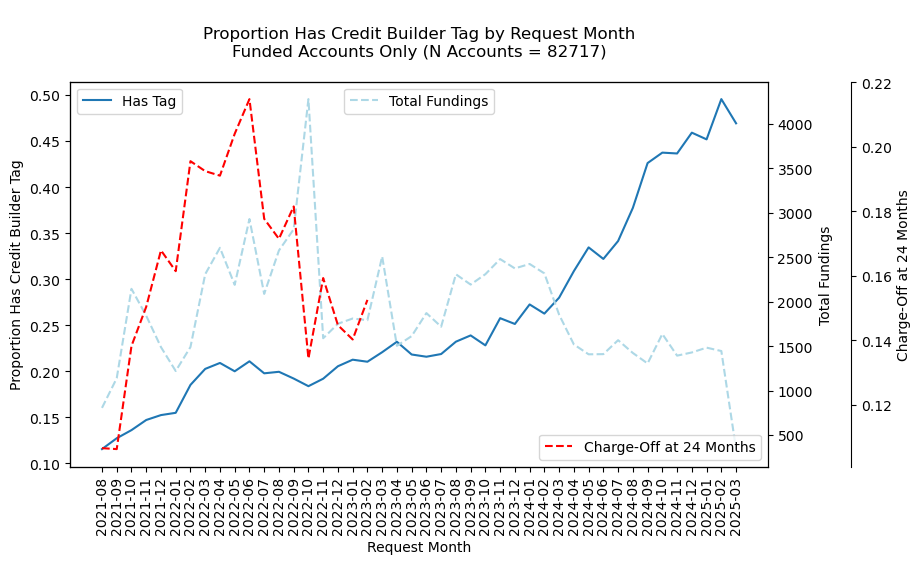

In [15]:
# graph
x = df_tmp['request_month']
y = df_tmp['has_inst_tag']
z = df_tmp['count']
a = df_tmp['co_at_720']

# ax
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Proportion Has Credit Builder Tag by Request Month
Funded Accounts Only (N Accounts = {int_nrows})
"""
ax.set_title(str_title)
ax.set_xlabel('Request Month')
ax.set_ylabel('Proportion Has Credit Builder Tag')
ax.plot(x, y, label='Has Tag')
ax.tick_params(axis='x', rotation=90)
ax.legend(loc='upper left')

# second y
ax2 = ax.twinx()
ax2.set_ylabel('Total Fundings')
ax2.plot(x, z, linestyle='--', color='lightblue', label='Total Fundings')
# legend
ax2.legend(loc='upper center')

# third y
ax3 = ax.twinx()
ax3.spines['right'].set_position(('outward', 60))  # prevent overlap
ax3.set_ylabel('Charge-Off at 24 Months')
ax3.plot(x[:19], a[:19], linestyle='--', color='red', label='Charge-Off at 24 Months')
# legend
ax3.legend(loc='lower right')

# save
str_filename = 'plt_fundings.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

#### Overlay income

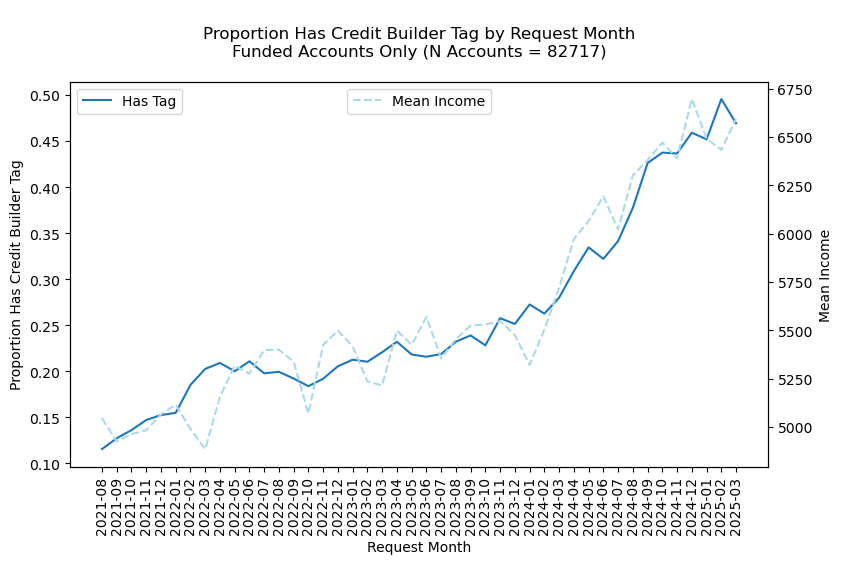

In [16]:
df_tmp = df.groupby(by='accountid', as_index=False).agg({
    'request_datetime': 'first',
    'has_inst_tag': 'max',
    'fltgrossmonthly__income_sum': 'sum',
})
int_nrows = df_tmp.shape[0]
df_tmp['request_month'] = df_tmp['request_datetime'].apply(
    lambda x: str(x)[:7],
)
df_tmp = df_tmp.groupby('request_month', as_index=False).agg({
    'has_inst_tag': 'mean',
    'fltgrossmonthly__income_sum': 'mean',
})

# graph
x = df_tmp['request_month']
y = df_tmp['has_inst_tag']
z = df_tmp['fltgrossmonthly__income_sum']
# ax
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Proportion Has Credit Builder Tag by Request Month
Funded Accounts Only (N Accounts = {int_nrows})
"""
ax.set_title(str_title)
ax.set_xlabel('Request Month')
ax.set_ylabel('Proportion Has Credit Builder Tag')
ax.plot(x, y, label='Has Tag')
ax.tick_params(axis='x', rotation=90)
ax.legend(loc='upper left')
# second y
ax2 = ax.twinx()
ax2.set_ylabel('Mean Income')
ax2.plot(x, z, linestyle='--', color='lightblue', label='Mean Income')
# legend
ax2.legend(loc='upper center')
# show
plt.show()

#### Maximum date

In [17]:
# get max date
dtm_max = df['request_datetime'].max()
print(f'Maximum date in data: {dtm_max}')

Maximum date in data: 2025-03-07 00:00:00


#### 60 in 720

In [18]:
int_ndays = 720
str_co_at = f'co_at_{int_ndays}'
# subtract n days
dtm_max_new = dtm_max - timedelta(days=int_ndays)
# make first of month
dtm_max_new = dtm_max_new.replace(day=1)
print(f'Subsetting to < {dtm_max_new}')
# subset
df_tmp = df[df['request_datetime'] < dtm_max_new].copy()
# group
df_tmp = df_tmp.groupby(by='accountid', as_index=False).agg({
    'request_month': 'first',
    'has_inst_tag': 'max',
    'gen12_pd': 'mean',
    'gen12_lgd': 'mean',
    'gen13_pd': 'mean',
    'gen13_lgd': 'mean',
    str_co_at: 'mean',
})
# make co at 72
df_tmp[str_co_at] = df_tmp[str_co_at] * flt_factor_24_to_72
# get ecnl
df_tmp['gen12_ecnl'] = df_tmp['gen12_pd'] * df_tmp['gen12_lgd'] * flt_factor_24_to_72
df_tmp['gen13_ecnl'] = df_tmp['gen13_pd'] * df_tmp['gen13_lgd'] * flt_factor_24_to_72

# show
df_tmp

Subsetting to < 2023-03-01 00:00:00


,accountid,request_month,has_inst_tag,gen12_pd,gen12_lgd,gen13_pd,gen13_lgd,co_at_720,gen12_ecnl,gen13_ecnl
0,5514485,2022-10,0,0.457846,0.630323,0.514540,0.390043,0.000000,0.681074,0.473634
1,5514970,2022-10,0,0.113772,0.646715,0.476924,0.390043,0.000000,0.173644,0.439008
2,5515245,2022-10,0,0.359690,0.636592,0.455095,0.350185,0.000000,0.540384,0.376107
3,5515340,2022-10,0,0.189438,0.640804,0.515241,0.416881,0.000000,0.286486,0.506915
4,5515580,2022-10,0,0.267427,0.625708,0.517352,0.390043,0.000000,0.394902,0.476223
...,...,...,...,...,...,...,...,...,...,...
38869,6640103,2023-02,0,0.391942,0.641387,0.542378,0.390043,0.000000,0.593273,0.499259
38870,6640191,2023-02,0,0.451202,0.651445,0.585688,0.350185,0.000000,0.693682,0.484034
38871,6642029,2023-02,0,0.236400,0.582366,0.442026,0.350185,1.307325,0.324904,0.365306
38872,6644832,2023-02,0,0.365560,0.617603,0.462637,0.337281,0.000000,0.532819,0.368251


#### Plot by month

In [19]:
list_cols = [
    'request_month',
    'has_inst_tag',
]
df_tmp['count'] = 1
df_tmp2 = df_tmp.groupby(by=list_cols, as_index=False).agg({
    'count': 'sum',
    'gen12_ecnl': 'sum',
    'gen13_ecnl': 'sum',
    'co_at_720': 'sum',
})
# subset
df_0 = df_tmp2[df_tmp2['has_inst_tag'] == 0].copy()
list_cols = [f'{col}_0' for col in df_0.columns]
df_0.columns = list_cols
# subset
df_1 = df_tmp2[df_tmp2['has_inst_tag'] == 1].copy()
list_cols = [f'{col}_1' for col in df_1.columns]
df_1.columns = list_cols
# concat
df_tmp2 = pd.merge(
    left=df_0,
    right=df_1,
    left_on='request_month_0',
    right_on='request_month_1',
    how='inner',
)
# drop
list_cols = [
    'has_inst_tag_0',
    'request_month_1',
    'has_inst_tag_1',
]
df_tmp2.drop(list_cols, axis=1, inplace=True)
# rename
dict_rename = {
    'request_month_0': 'request_month',
}
df_tmp2.rename(columns=dict_rename, inplace=True)
# cumsums
list_cols = [col for col in df_tmp2.columns if col != 'request_month']
for col in tqdm(list_cols):
    df_tmp2[col] = df_tmp2[col].cumsum()
# cummeans
list_cols = [
    'gen12_ecnl_0',
    'gen13_ecnl_0',
    'co_at_720_0',
]
for col in tqdm(list_cols):
    df_tmp2[col] = df_tmp2[col] / df_tmp2['count_0']
# cummeans
list_cols = [
    'gen12_ecnl_1',
    'gen13_ecnl_1',
    'co_at_720_1',
]
for col in tqdm(list_cols):
    df_tmp2[col] = df_tmp2[col] / df_tmp2['count_1']

# create factors
df_tmp2['gen12_factor_0'] = df_tmp2['co_at_720_0'] / df_tmp2['gen12_ecnl_0']
df_tmp2['gen12_factor_1'] = df_tmp2['co_at_720_1'] / df_tmp2['gen12_ecnl_1']
# create factors
df_tmp2['gen13_factor_0'] = df_tmp2['co_at_720_0'] / df_tmp2['gen13_ecnl_0']
df_tmp2['gen13_factor_1'] = df_tmp2['co_at_720_1'] / df_tmp2['gen13_ecnl_1']

# show
df_tmp2

100%|██████████| 3/3 [00:00<00:00, 4718.00it/s]


,request_month,count_0,gen12_ecnl_0,gen13_ecnl_0,co_at_720_0,count_1,gen12_ecnl_1,gen13_ecnl_1,co_at_720_1,gen12_factor_0,gen12_factor_1,gen13_factor_0,gen13_factor_1
0,2021-08,712,0.365039,0.343111,0.239327,93,0.459348,0.405521,0.345410,0.655620,0.751956,0.697519,0.851769
1,2021-09,1706,0.382063,0.355858,0.233229,238,0.480716,0.422959,0.379834,0.610446,0.790142,0.655399,0.898040
2,2021-10,3559,0.407628,0.374837,0.273638,530,0.488505,0.430293,0.404438,0.671293,0.827910,0.730019,0.939913
3,2021-11,5130,0.415456,0.379480,0.294173,801,0.491713,0.436592,0.415730,0.708072,0.845472,0.775201,0.952215
4,2021-12,6392,0.419033,0.381378,0.310598,1028,0.491246,0.438816,0.434630,0.741227,0.884749,0.814411,0.990461
5,2022-01,7423,0.422405,0.384040,0.317726,1217,0.491743,0.439039,0.442497,0.752183,0.899854,0.827325,1.007875
6,2022-02,8637,0.427403,0.386834,0.332129,1493,0.498684,0.445690,0.479564,0.777087,0.961660,0.858584,1.076004
7,2022-03,10479,0.434400,0.392875,0.348212,1961,0.503935,0.451832,0.502215,0.801594,0.996587,0.886318,1.111509
8,2022-04,12541,0.438216,0.396690,0.361046,2506,0.509013,0.456410,0.511316,0.823899,1.004526,0.910146,1.120301
9,2022-05,14293,0.441281,0.399084,0.371304,2944,0.511739,0.458431,0.528761,0.841422,1.033264,0.930391,1.153415


100%|██████████| 4/4 [00:00<00:00, 454.62it/s]


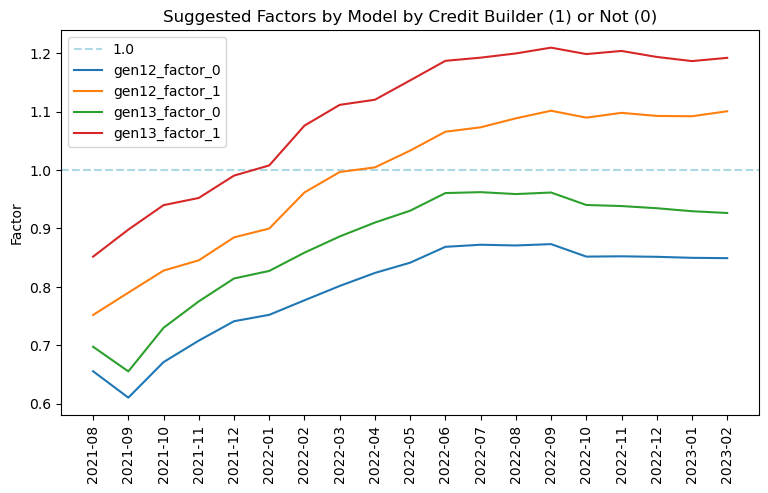

In [20]:
list_cols = [
    'gen12_factor_0',
    'gen12_factor_1',
    'gen13_factor_0',
    'gen13_factor_1',
]
x = df_tmp2['request_month']
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Suggested Factors by Model by Credit Builder (1) or Not (0)')
ax.set_ylabel('Factor')
ax.axhline(1, linestyle='--', color='lightblue', label='1.0')
for col in tqdm(list_cols):
    ax.plot(x, df_tmp2[col], label=col)
# xtick labels
ax.set_xticklabels(x, rotation=90)
# legend
ax.legend()
# show
plt.show()